## HMM Baseball Project EDA: Exploring the Dataset

Import relevant packages, load data

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
df = pd.read_csv('hmm_data.csv')
df.head()

,player_name,game_date,release_speed,pitch_number,at_bat_number
0,"Webb, Logan",2024-04-07,92.2,2,52
1,"Webb, Logan",2024-04-07,92.1,3,20
2,"Webb, Logan",2024-04-07,91.9,2,20
3,"Webb, Logan",2024-04-07,92.1,2,3
4,"Gausman, Kevin",2024-04-06,90.4,4,19


Here pitch number, is within an at bat. At bat number is sequential

In [7]:
df['pitch_number'].max()

12

In [8]:
df['pitch_number'].min()

1

For simplicity, narrow down the dataset to a single pitcher (Cole, Gerrit)

In [9]:
df_filtered = df[df['player_name'] == 'Cole, Gerrit']
# Scale by season average, could also be season max if necessary
df_filtered['release_speed'] = df_filtered['release_speed']/df_filtered['release_speed'].mean() * 100
df_filtered

/var/folders/bj/k66kcb9s727dg1rlfb27jp_c0000gn/T/ipykernel_64589/2438781518.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['release_speed'] = df_filtered['release_speed']/df_filtered['release_speed'].mean() * 100


,player_name,game_date,release_speed,pitch_number,at_bat_number
1181,"Cole, Gerrit",2024-06-19,99.127423,1,33
1183,"Cole, Gerrit",2024-06-19,100.169772,6,29
1184,"Cole, Gerrit",2024-06-19,99.857067,5,29
1186,"Cole, Gerrit",2024-06-19,98.397778,4,29
1187,"Cole, Gerrit",2024-06-19,99.961302,3,29
...,...,...,...,...,...
3309,"Cole, Gerrit",2024-09-26,97.563899,2,2
3310,"Cole, Gerrit",2024-09-26,97.876603,1,2
3311,"Cole, Gerrit",2024-09-26,99.023188,5,1
3312,"Cole, Gerrit",2024-09-26,99.127423,3,1


In [10]:
# Testing on a single date
game_test = df_filtered[df_filtered['game_date'] == '2024-06-19']
game_test

,player_name,game_date,release_speed,pitch_number,at_bat_number
1181,"Cole, Gerrit",2024-06-19,99.127423,1,33
1183,"Cole, Gerrit",2024-06-19,100.169772,6,29
1184,"Cole, Gerrit",2024-06-19,99.857067,5,29
1186,"Cole, Gerrit",2024-06-19,98.397778,4,29
1187,"Cole, Gerrit",2024-06-19,99.961302,3,29
1191,"Cole, Gerrit",2024-06-19,99.857067,5,28
1192,"Cole, Gerrit",2024-06-19,98.710483,4,28
1195,"Cole, Gerrit",2024-06-19,97.876603,2,28
1196,"Cole, Gerrit",2024-06-19,97.563899,4,27
1201,"Cole, Gerrit",2024-06-19,100.378242,4,23


In [11]:
# Sort game to get at bat number and pitch number in right order
sorted_game = game_test.sort_values(by = ['at_bat_number', 'pitch_number'], ascending = True)
sorted_game

,player_name,game_date,release_speed,pitch_number,at_bat_number
1249,"Cole, Gerrit",2024-06-19,98.189308,1,1
1247,"Cole, Gerrit",2024-06-19,98.085073,2,1
1245,"Cole, Gerrit",2024-06-19,101.107886,1,2
1242,"Cole, Gerrit",2024-06-19,100.690947,3,2
1240,"Cole, Gerrit",2024-06-19,99.752832,4,2
1236,"Cole, Gerrit",2024-06-19,99.231657,1,5
1234,"Cole, Gerrit",2024-06-19,97.459664,1,12
1232,"Cole, Gerrit",2024-06-19,97.563899,3,12
1230,"Cole, Gerrit",2024-06-19,97.772368,4,12
1229,"Cole, Gerrit",2024-06-19,98.606248,2,13


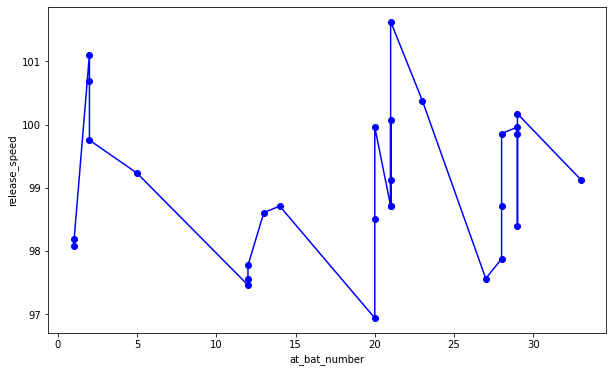

In [12]:
# Plotting for one game
plt.figure(figsize=(10, 6))
plt.plot(sorted_game['at_bat_number'], sorted_game['release_speed'], marker='o', linestyle='-', color='b')
plt.ylabel('release_speed')
plt.xlabel('at_bat_number')
plt.show()

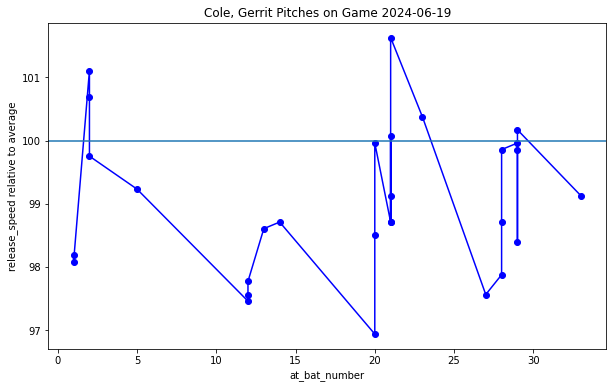

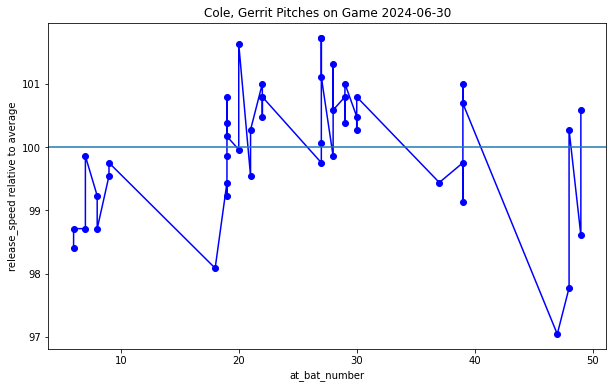

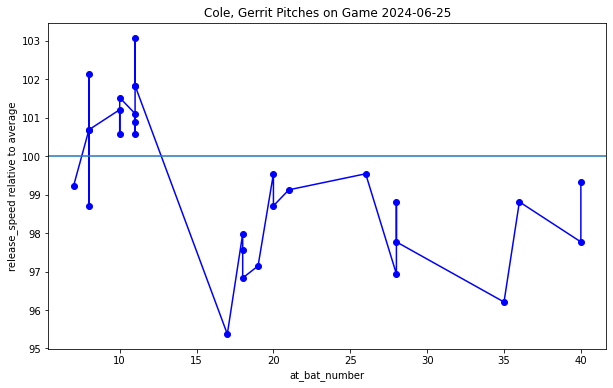

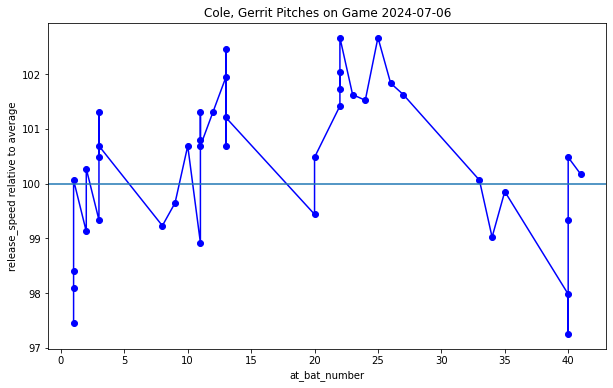

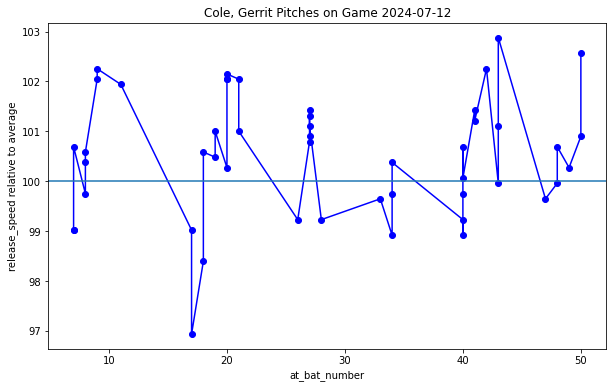

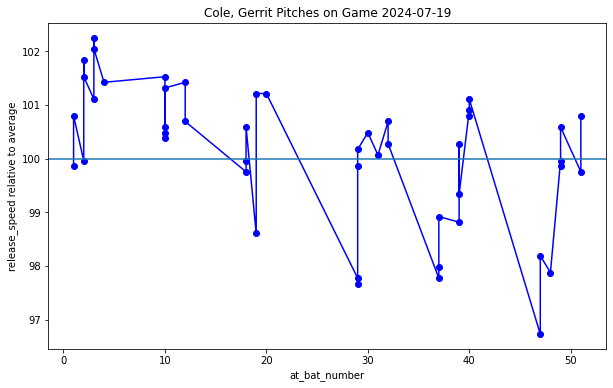

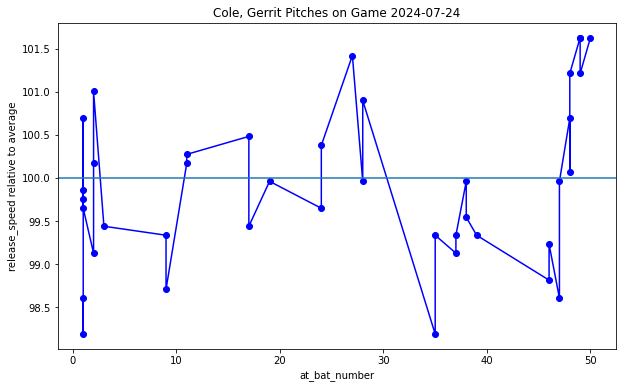

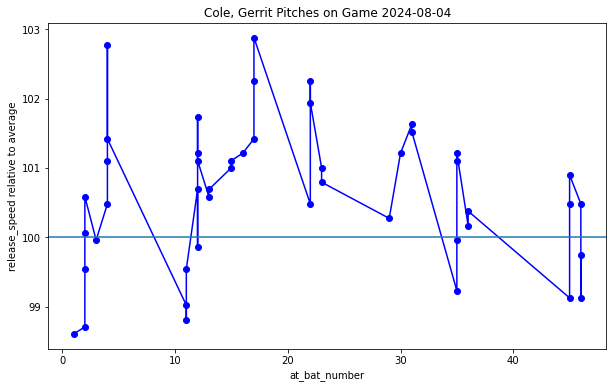

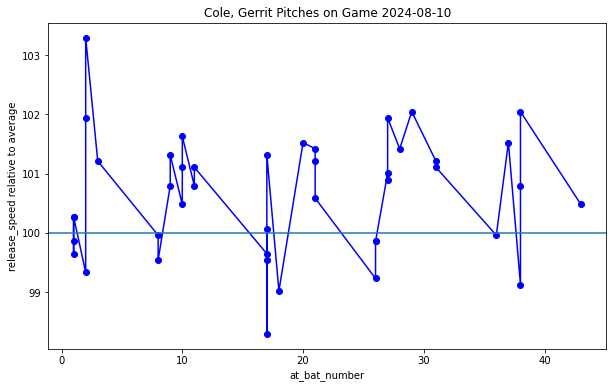

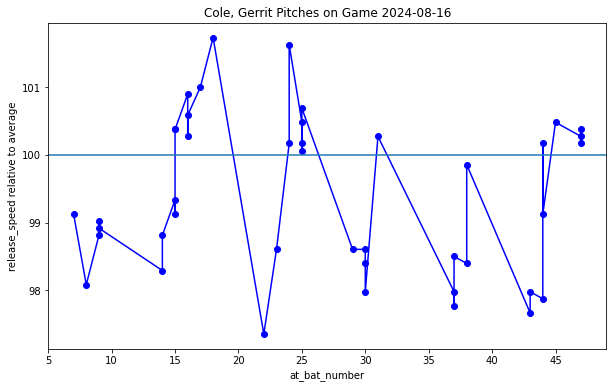

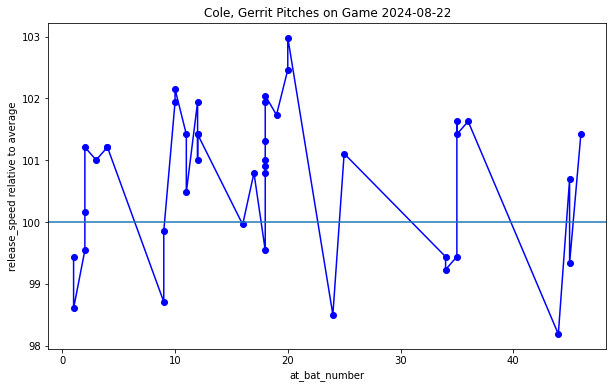

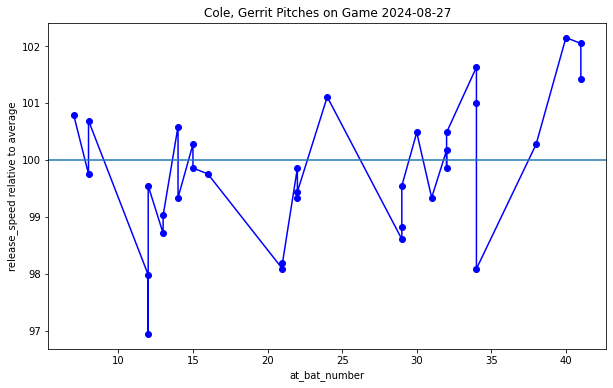

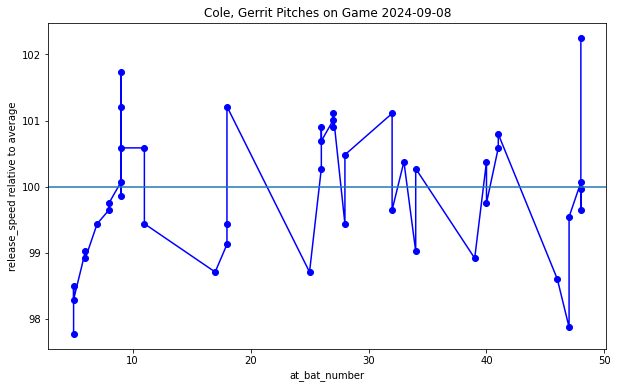

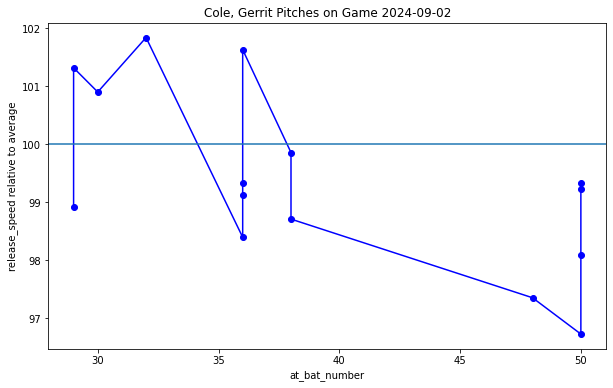

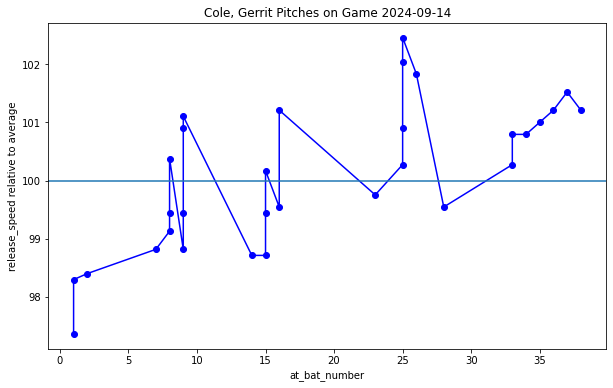

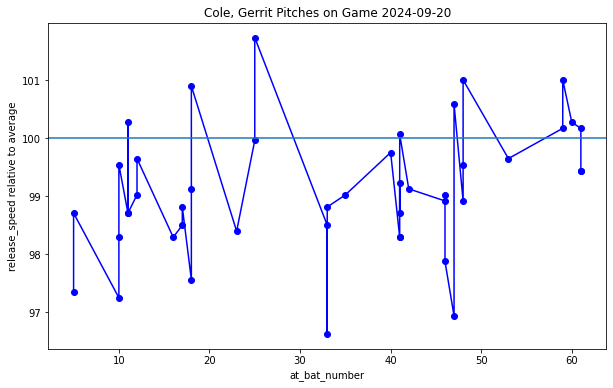

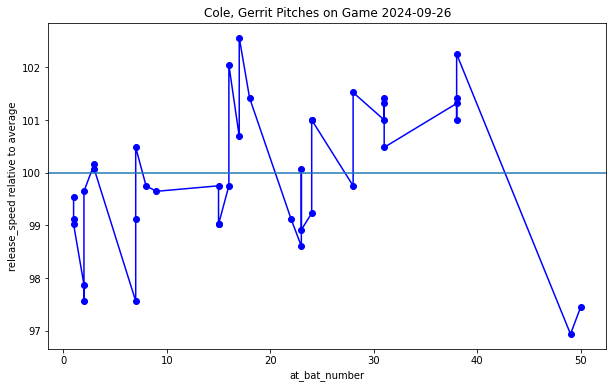

In [13]:
# Going through every game of the season 
game_list = list(df_filtered['game_date'].unique())
for g in game_list:
    game_test = df_filtered[df_filtered['game_date'] == g]
    sorted_game = game_test.sort_values(by = ['at_bat_number', 'pitch_number'], ascending = True)
    plt.figure(figsize=(10, 6))
    plt.title(f'Cole, Gerrit Pitches on Game {g}')
    plt.plot(sorted_game['at_bat_number'], sorted_game['release_speed'], marker='o', linestyle='-', color='b')
    plt.ylabel('release_speed relative to average')
    plt.xlabel('at_bat_number')
    plt.axhline(100)
    plt.show()
    